 Name:- Shivam Nangare
 Roll No.ACT-45

In [1]:
# 1.Load in a pre-trained CNN model trained on a large dataset
# 2.Freeze parameters (weights) in model’s lower convolutional layers
# 3.Add custom classifier with several layers of trainable parameters to model
# 4.Train classifier layers on training data available for task
# 5.Fine-tune hyper parameters and unfreeze more layers as needed

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Class labels
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

In [4]:
# Load CIFAR10 Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [5]:
# Normalize and resize
def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

In [6]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess).batch(16).take(200)

In [7]:
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess).batch(3)

In [8]:
# Load Pretrained Model
print("Step 1: Loading pretrained ResNet50...")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

Step 1: Loading pretrained ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# Freeze base layers
print("Step 2: Freezing base layers...")
for layer in base_model.layers:
    layer.trainable = False

Step 2: Freezing base layers...


In [10]:
# Add Custom Classifier
print("Step 3: Adding custom classifier...")
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(10, activation='softmax')(x)

Step 3: Adding custom classifier...


In [11]:
model = models.Model(inputs=base_model.input, outputs=outputs)

In [12]:
# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
# Train Classifier
print("\n--- Training Classifier ---")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    min_delta=0.005,
    restore_best_weights=True
)


--- Training Classifier ---


In [14]:
model.fit(train_ds, epochs=5, callbacks=[early_stop])

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.7347 - loss: 0.7898
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.8816 - loss: 0.3584
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9122 - loss: 0.2477
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9372 - loss: 0.1857
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9491 - loss: 0.1376


In [15]:
# Fine-Tuning
print("\n--- Fine-Tuning: Unfreezing last block ---")

for layer in base_model.layers[-30:]:  # Unfreeze last layers
    layer.trainable = True


--- Fine-Tuning: Unfreezing last block ---


In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.fit(train_ds, epochs=5, callbacks=[early_stop])

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.9250 - loss: 0.2233
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.9822 - loss: 0.0812
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.9956 - loss: 0.0378
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.9987 - loss: 0.0245
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.9987 - loss: 0.0177


In [18]:
# Testing + Visualization

def test_and_visualize(model, test_ds):
    print("\n--- Testing Phase ---")

    for images, labels in test_ds.take(1):
        preds = model.predict(images)

        pred_labels = np.argmax(preds, axis=1)
        confidences = np.max(preds, axis=1)

        fig, axes = plt.subplots(1, 3, figsize=(12,5))
        for i in range(3):
            img = images[i].numpy()
            img = (img - img.min()) / (img.max() - img.min())

            true_label = labels[i].numpy()[0]
            pred_label = pred_labels[i]

            axes[i].imshow(img)
            axes[i].axis('off')


            text = f"True: {classes[true_label]}\nPred: {classes[pred_label]}\n({confidences[i]*100:.1f}%)"
            color = 'green' if true_label == pred_label else 'red'

            axes[i].set_title(text, color=color)

            print(f"Image {i+1}: True={classes[true_label]}, Pred={classes[pred_label]} ({confidences[i]:.2%})")

        plt.tight_layout()
        plt.savefig("lab9_tf_result.png")
        plt.show()


--- Testing Phase ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Image 1: True=cat, Pred=cat (100.00%)
Image 2: True=ship, Pred=ship (100.00%)
Image 3: True=ship, Pred=automobile (54.21%)


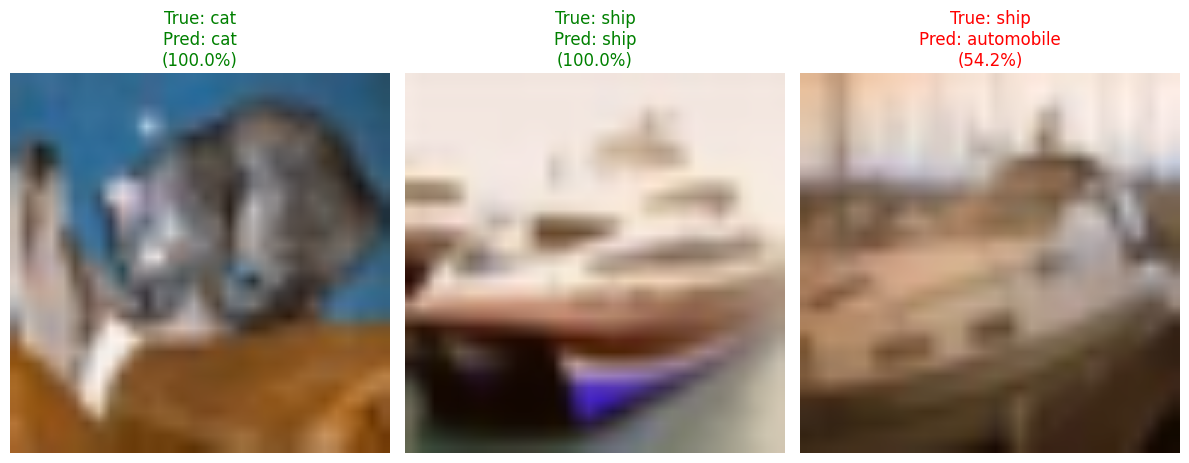

In [19]:
# Run testing
test_and_visualize(model, test_ds)

In [20]:
print("TensorFlow Lab 9 Completed Successfully!")

TensorFlow Lab 9 Completed Successfully!
